# Análise Exploratória — Bank Marketing

Este notebook executa a camada de tradução e validação do M1 a partir do snapshot bruto. O objetivo é compreender qualidade, desbalanceamento, canais e histórico de campanha sem criar transformações exclusivas no notebook.

**Unidade de observação:** registro de contato de uma campanha.  
**Target:** `resultado`, igual a 1 quando houve assinatura do depósito a prazo.  
**Ação histórica:** `canal_contato`, com os braços `celular` e `telefone`.  
**Atenção:** associações históricas não representam efeito causal.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.api.types import is_string_dtype

# Localiza a raiz independentemente de o notebook iniciar na raiz ou em notebooks/.
current_path = Path.cwd().resolve()
project_root = current_path if (current_path / "configs").exists() else current_path.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.data.translate import build_interim_dataset
from src.data.validate import validate_translated_dataset

data_config_path = project_root / "configs" / "data.yaml"
sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 30)

## 1. Construção reproduzível da camada PT-BR

A função abaixo verifica o SHA-256 da fonte, valida schema e categorias, traduz os 21 campos, cria `event_id` e grava a camada `interim`.

In [2]:
# Executa a mesma função usada pela linha de comando e pelos testes.
translated_frame, lineage_metadata = build_interim_dataset(data_config_path)
validation_report = validate_translated_dataset(translated_frame)

pd.DataFrame(
    {
        "indicador": ["registros", "colunas", "células nulas", "duplicatas de negócio"],
        "valor": [
            validation_report.row_count,
            validation_report.column_count,
            validation_report.null_cell_count,
            validation_report.duplicate_business_rows,
        ],
    }
)

,indicador,valor
0,registros,41188
1,colunas,22
2,células nulas,0
3,duplicatas de negócio,12


In [3]:
translated_frame.head()

,event_id,idade,profissao,estado_civil,escolaridade,inadimplencia,financiamento_habitacional,emprestimo_pessoal,canal_contato,mes_contato,dia_semana,duracao_contato,contatos_campanha_atual,dias_desde_ultimo_contato,contatos_campanhas_anteriores,resultado_campanha_anterior,taxa_variacao_emprego,indice_precos_consumidor,indice_confianca_consumidor,euribor_3_meses,numero_empregados,resultado
0,1,56,trabalhador_domestico,casado,basico_4_anos,nao,nao,nao,telefone,mai,seg,261,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,0
1,2,57,servicos,casado,ensino_medio,desconhecido,nao,nao,telefone,mai,seg,149,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,0
2,3,37,servicos,casado,ensino_medio,nao,sim,nao,telefone,mai,seg,226,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,0
3,4,40,administrativo,casado,basico_6_anos,nao,nao,nao,telefone,mai,seg,151,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,0
4,5,56,servicos,casado,ensino_medio,nao,nao,sim,telefone,mai,seg,307,1,999,0,inexistente,1.1,93.994,-36.4,4.857,5191.0,0


As 12 duplicatas são calculadas sem `event_id`. Elas permanecem nesta camada para preservar paridade com a fonte e serão removidas de forma versionada no M2.

## 2. Distribuição do target

In [4]:
target_summary = (
    translated_frame["resultado"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("resultado")
    .to_frame("registros")
)
target_summary["proporcao"] = target_summary["registros"] / len(translated_frame)
target_summary

,registros,proporcao
resultado,,
0,36548,0.887346
1,4640,0.112654


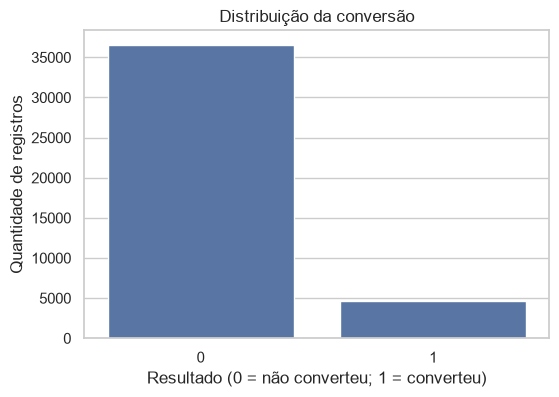

In [5]:
figure, axis = plt.subplots(figsize=(6, 4))
sns.countplot(data=translated_frame, x="resultado", ax=axis)
axis.set(
    title="Distribuição da conversão",
    xlabel="Resultado (0 = não converteu; 1 = converteu)",
    ylabel="Quantidade de registros",
)
plt.show()

A classe positiva representa aproximadamente 11,3% dos registros. Acurácia isolada será inadequada; a modelagem deverá priorizar PR-AUC, calibração e métricas por classe.

## 3. Qualidade semântica e valores desconhecidos

`desconhecido` não é nulo técnico. A categoria representa ausência semântica informada pela fonte e deve ser preservada e monitorada.

In [6]:
string_columns = [
    column for column in translated_frame.columns if is_string_dtype(translated_frame[column].dtype)
]
unknown_summary = pd.DataFrame(
    [
        {
            "coluna": column,
            "quantidade": int(translated_frame[column].eq("desconhecido").sum()),
            "proporcao": translated_frame[column].eq("desconhecido").mean(),
        }
        for column in string_columns
        if translated_frame[column].eq("desconhecido").any()
    ]
).sort_values("proporcao", ascending=False)
unknown_summary

,coluna,quantidade,proporcao
3,inadimplencia,8597,0.208726
2,escolaridade,1731,0.042027
4,financiamento_habitacional,990,0.024036
5,emprestimo_pessoal,990,0.024036
0,profissao,330,0.008012
1,estado_civil,80,0.001942


## 4. Perfil numérico

In [7]:
numeric_columns = translated_frame.select_dtypes(include="number").columns.drop(
    ["event_id", "resultado"]
)
translated_frame[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
idade,41188.0,40.024060,10.421250,17.000,32.000,38.000,47.000,98.000
duracao_contato,41188.0,258.285010,259.279249,0.000,102.000,180.000,319.000,4918.000
contatos_campanha_atual,41188.0,2.567593,2.770014,1.000,1.000,2.000,3.000,56.000
dias_desde_ultimo_contato,41188.0,962.475454,186.910907,0.000,999.000,999.000,999.000,999.000
contatos_campanhas_anteriores,41188.0,0.172963,0.494901,0.000,0.000,0.000,0.000,7.000
taxa_variacao_emprego,41188.0,0.081886,1.570960,-3.400,-1.800,1.100,1.400,1.400
indice_precos_consumidor,41188.0,93.575664,0.578840,92.201,93.075,93.749,93.994,94.767
indice_confianca_consumidor,41188.0,-40.502600,4.628198,-50.800,-42.700,-41.800,-36.400,-26.900
euribor_3_meses,41188.0,3.621291,1.734447,0.634,1.344,4.857,4.961,5.045
numero_empregados,41188.0,5167.035911,72.251528,4963.600,5099.100,5191.000,5228.100,5228.100


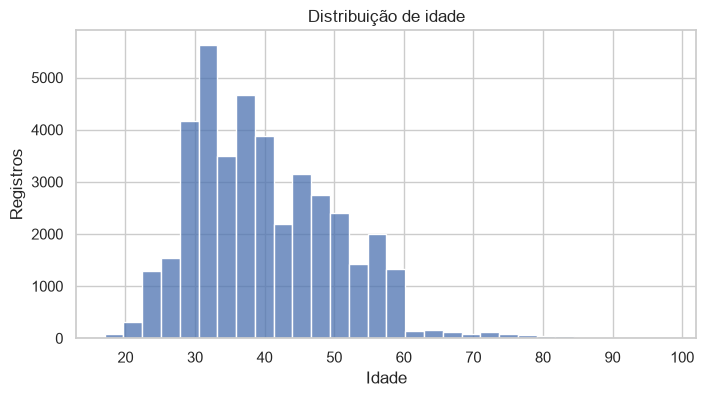

In [8]:
figure, axis = plt.subplots(figsize=(8, 4))
sns.histplot(data=translated_frame, x="idade", bins=30, ax=axis)
axis.set(title="Distribuição de idade", xlabel="Idade", ylabel="Registros")
plt.show()

`idade` é campo somente de auditoria no MVP. O gráfico descreve a base, mas não autoriza seu uso para escolher o canal.

## 5. Conversão observada por canal

In [9]:
channel_summary = (
    translated_frame.groupby("canal_contato", observed=True)["resultado"]
    .agg(registros="size", conversoes="sum", taxa_conversao="mean")
    .sort_values("taxa_conversao", ascending=False)
)
channel_summary

,registros,conversoes,taxa_conversao
canal_contato,,,
celular,26144,3853,0.147376
telefone,15044,787,0.052313


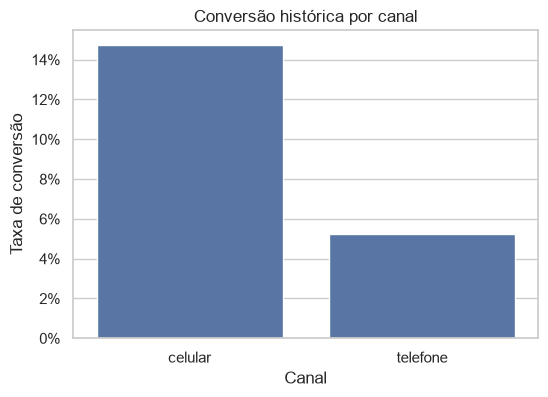

In [10]:
figure, axis = plt.subplots(figsize=(6, 4))
sns.barplot(
    data=channel_summary.reset_index(),
    x="canal_contato",
    y="taxa_conversao",
    ax=axis,
)
axis.set(title="Conversão histórica por canal", xlabel="Canal", ylabel="Taxa de conversão")
axis.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.show()

O canal celular possui conversão histórica superior, mas a alocação não foi randomizada. Diferenças de público, período e estratégia podem explicar parte ou todo o resultado.

## 6. Histórico de campanhas

In [11]:
previous_outcome_summary = (
    translated_frame.groupby("resultado_campanha_anterior", observed=True)["resultado"]
    .agg(registros="size", conversoes="sum", taxa_conversao="mean")
    .sort_values("taxa_conversao", ascending=False)
)
previous_outcome_summary

,registros,conversoes,taxa_conversao
resultado_campanha_anterior,,,
sucesso,1373,894,0.651129
fracasso,4252,605,0.142286
inexistente,35563,3141,0.088322


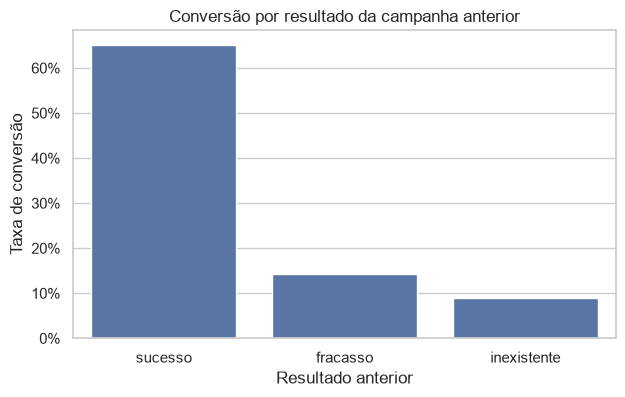

In [12]:
figure, axis = plt.subplots(figsize=(7, 4))
sns.barplot(
    data=previous_outcome_summary.reset_index(),
    x="resultado_campanha_anterior",
    y="taxa_conversao",
    ax=axis,
)
axis.set(
    title="Conversão por resultado da campanha anterior",
    xlabel="Resultado anterior",
    ylabel="Taxa de conversão",
)
axis.yaxis.set_major_formatter(lambda value, position: f"{value:.0%}")
plt.show()

## 7. Demonstração do vazamento por duração

In [13]:
duration_summary = translated_frame.groupby("resultado")["duracao_contato"].agg(
    registros="size",
    media="mean",
    mediana="median",
)
duration_summary

,registros,media,mediana
resultado,,,
0,36548,220.844807,163.5
1,4640,553.191164,449.0


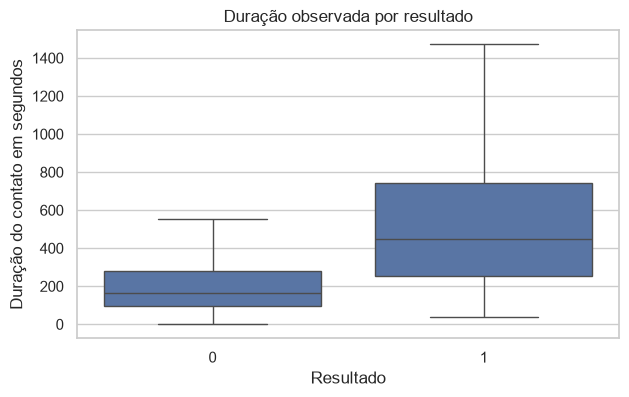

In [14]:
figure, axis = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=translated_frame,
    x="resultado",
    y="duracao_contato",
    showfliers=False,
    ax=axis,
)
axis.set(
    title="Duração observada por resultado",
    xlabel="Resultado",
    ylabel="Duração do contato em segundos",
)
plt.show()

A duração média é muito maior entre conversões, mas só é conhecida após o contato. Ela permanece na camada canônica para auditoria desta evidência e está bloqueada no contrato do experimento; o M2 deverá excluí-la das features.

## 8. Fatia de auditoria por profissão

In [15]:
profession_audit = (
    translated_frame.groupby("profissao", observed=True)["resultado"]
    .agg(registros="size", conversoes="sum", taxa_conversao="mean")
    .sort_values("taxa_conversao", ascending=False)
)
profession_audit

,registros,conversoes,taxa_conversao
profissao,,,
estudante,875,275,0.314286
aposentado,1720,434,0.252326
desempregado,1014,144,0.142012
administrativo,10422,1352,0.129726
gestao,2924,328,0.112175
desconhecido,330,37,0.112121
tecnico,6743,730,0.108260
autonomo,1421,149,0.104856
trabalhador_domestico,1060,106,0.100000


A análise por profissão serve para identificar disparidades e possíveis proxies. O contrato do M0 classifica esse campo como somente auditoria, portanto ele não entra diretamente na política do MVP.

## 9. Conclusões e decisões para o M2

- A tradução mantém 41.188 registros, 21 campos de negócio e adiciona um identificador técnico estável.
- Não há nulos técnicos, mas seis campos contêm a categoria `desconhecido`; inadimplência possui a maior incidência.
- Existem 12 duplicatas de negócio, preservadas no M1 e destinadas à remoção controlada no M2.
- A conversão positiva é de aproximadamente 11,3%, confirmando o desbalanceamento.
- Celular apresenta maior conversão histórica, mas a associação não é causal.
- Resultado anterior é informativo e está disponível antes da nova decisão.
- Duração é um vazamento pós-contato e deve ser bloqueada antes do treino.
- Campos demográficos e financeiros permanecem somente para auditoria no MVP.

O M2 deverá remover duplicatas, derivar a sentinela de contato anterior, separar ação/target/contexto e criar splits antes de ajustar qualquer transformação.